# Robust Feature Extractor Comparison

Compares `GeometricFeatureExtractor` (9-dim) against `RobustGeometricFeatureExtractor`
(11-dim) on two axes:

- **Part A — clustering stability**: how much does feature-space DBSCAN clustering
  change when a cloud is perturbed with dropout (random point removal) and jitter
  (Gaussian positional noise)? Includes a `k` (neighbor count) sweep to pick a fair
  operating point per style/extractor before comparing stability.
- **Part B — ICP convergence**: how does each extractor perform as the feature
  source for `NearestNeighborMatcher` inside `MultiStartICP`, clean vs. degraded
  (dropout + noise)?

Both parts sweep across all cloud styles from `synthetic.py` (`random`, `clustered`,
`lattice`, `2d-lattice`, `muscle-fiber`).

In [1]:
import sys
sys.path.insert(0, '../src')

from typing import Any

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score
from tabulate import tabulate

from point_cloud import PointCloud
from synthetic import SyntheticExperiment, CloudStyle
from feature_extractor import GeometricFeatureExtractor, RobustGeometricFeatureExtractor, zscored_features
from matcher import NearestNeighborMatcher
from icp import ICP, MultiStartICP
from experiment_runner import fit_multi_seed
from visualization import ErrorMetricsVisualizer, TimeVisualizer

STYLES: list[CloudStyle] = ['random', 'clustered', 'lattice', '2d-lattice', 'muscle-fiber']
EXTRACTOR_LABELS = ['Baseline (9-dim)', 'Robust (11-dim)']
EXTRACTOR_CLASSES = [GeometricFeatureExtractor, RobustGeometricFeatureExtractor]
EXTRACTOR_COLORS = {'Baseline (9-dim)': 'tab:blue', 'Robust (11-dim)': 'tab:orange'}
SEED = 0

## Part A — Clustering stability under dropout + jitter

For each cloud style, cluster the feature vectors of a clean cloud with DBSCAN, then
perturb the same cloud with dropout (random point removal) and jitter (Gaussian
positional noise), re-cluster, and compare the perturbed labels to the clean labels
— restricted to points that survived dropout — via the Adjusted Rand Index (ARI).
ARI = 1 means the perturbation didn't change which points get grouped together;
ARI = 0 means agreement no better than random. A feature extractor whose vectors are
more resilient to dropout should show a higher ARI at a given severity.

In [2]:
N_POINTS_CLUSTER = 3000

# (label, dropout_prob, jitter_std) — severity increases jointly in both axes.
SEVERITY_LEVELS = [
    ('none', 0.0, 0.0),
    ('mild', 0.05, 0.3),
    ('moderate', 0.15, 0.8),
    ('severe', 0.30, 1.5),
]
N_REPEATS = 5

K_SWEEP = [5, 8, 12, 15, 20, 25, 35, 50]
N_REPEATS_K_SWEEP = 3

In [3]:
def cluster_labels(cloud: PointCloud, extractor) -> np.ndarray:
    """DBSCAN cluster labels for a cloud's z-scored feature vectors.

    Args:
        cloud: Point cloud with N points.
        extractor: FeatureExtractor producing per-point features.

    Returns:
        Per-point cluster label array of shape (N,); -1 marks noise.
    """
    features = zscored_features(extractor, [cloud])[0]
    d = features.shape[1]
    eps = (2 * d) ** 0.5 * 0.2
    db = DBSCAN(eps=eps, min_samples=int(np.log(len(cloud))))
    db.fit(features)
    return db.labels_


def perturb(
    cloud: PointCloud, dropout_prob: float, jitter_std: float, rng: np.random.Generator
) -> tuple[PointCloud, np.ndarray]:
    """Apply dropout (point removal) and Gaussian jitter to a cloud.

    Args:
        cloud: Point cloud to perturb.
        dropout_prob: Per-point probability of being dropped.
        jitter_std: Std of additive per-point Gaussian noise.
        rng: Random generator for reproducibility.

    Returns:
        Tuple of (perturbed cloud, boolean mask of points that survived dropout).
    """
    mask = rng.uniform(size=len(cloud)) >= dropout_prob
    points = cloud.points[mask] + rng.normal(0, jitter_std, size=(int(mask.sum()), 3))
    return PointCloud(points), mask


def stability_ari(
    clean_labels: np.ndarray,
    cloud: PointCloud,
    extractor,
    dropout_prob: float,
    jitter_std: float,
    rng: np.random.Generator,
) -> float:
    """Adjusted Rand Index between clean and perturbed cluster labels.

    Args:
        clean_labels: Cluster labels of the unperturbed cloud.
        cloud: The same (unperturbed) point cloud clean_labels was computed from.
        extractor: FeatureExtractor used for clustering.
        dropout_prob: Per-point dropout probability applied before re-clustering.
        jitter_std: Std of Gaussian jitter applied before re-clustering.
        rng: Random generator for reproducibility.

    Returns:
        ARI between clean labels (restricted to surviving points) and perturbed
        labels. 1.0 when dropout_prob == jitter_std == 0, by construction.
    """
    if dropout_prob == 0.0 and jitter_std == 0.0:
        return 1.0
    perturbed_cloud, mask = perturb(cloud, dropout_prob, jitter_std, rng)
    perturbed_labels = cluster_labels(perturbed_cloud, extractor)
    return float(adjusted_rand_score(clean_labels[mask], perturbed_labels))

### Tuning k per style/extractor

Neighborhood size `k` controls how much geometric context each feature vector
summarizes: too small and features are dominated by noise from whichever few
points happen to be nearby; too large and distinct regions get smoothed
together. Rather than fixing `k` globally, sweep it per (style, extractor) and
pick the value that best preserves clustering agreement at *mild* perturbation
— a `k` that's already unstable at the mildest dropout/jitter level is a poor
choice regardless of how it behaves further out.

In [4]:
clouds_by_style = {style: SyntheticExperiment.generate(n=N_POINTS_CLUSTER, style=style, seed=SEED).S for style in STYLES}
mild_dropout, mild_jitter = next((dp, js) for label, dp, js in SEVERITY_LEVELS if label == 'mild')

rng_k = np.random.default_rng(SEED)
# (style, extractor) -> (len(K_SWEEP), N_REPEATS_K_SWEEP) ARI array, as expected by
# ErrorMetricsVisualizer.plot_parameter_sweep (mean/std computed over axis=1).
k_sweep_data: dict[tuple[str, str], np.ndarray] = {}

for style in STYLES:
    cloud = clouds_by_style[style]
    for ext_name, ext_cls in zip(EXTRACTOR_LABELS, EXTRACTOR_CLASSES):
        arr = np.empty((len(K_SWEEP), N_REPEATS_K_SWEEP))
        for i, k in enumerate(K_SWEEP):
            extractor = ext_cls(k=k)
            clean_labels = cluster_labels(cloud, extractor)
            for r in range(N_REPEATS_K_SWEEP):
                arr[i, r] = stability_ari(clean_labels, cloud, extractor, mild_dropout, mild_jitter, rng_k)
        k_sweep_data[(style, ext_name)] = arr

print(f'{len(k_sweep_data)} (style, extractor) sweeps over {len(K_SWEEP)} k values evaluated')

10 (style, extractor) sweeps over 8 k values evaluated


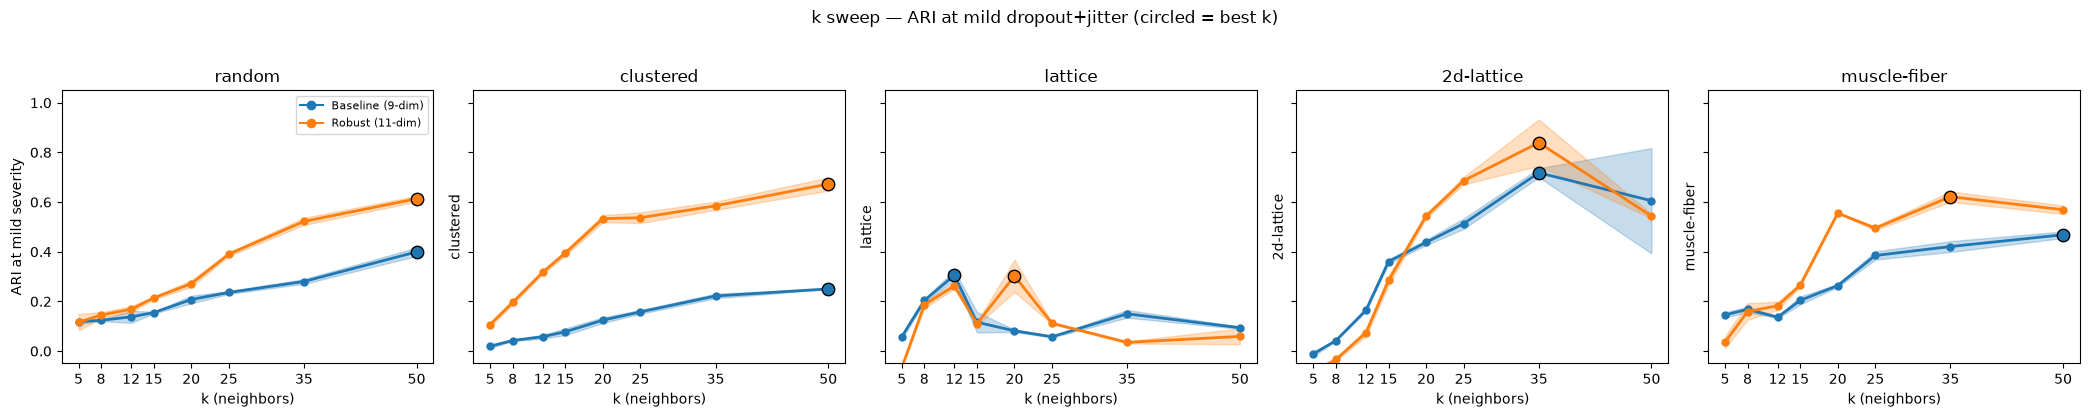

| style        | extractor        |   best k |
|--------------|------------------|----------|
| random       | Baseline (9-dim) |       50 |
| random       | Robust (11-dim)  |       50 |
| clustered    | Baseline (9-dim) |       50 |
| clustered    | Robust (11-dim)  |       50 |
| lattice      | Baseline (9-dim) |       12 |
| lattice      | Robust (11-dim)  |       20 |
| 2d-lattice   | Baseline (9-dim) |       35 |
| 2d-lattice   | Robust (11-dim)  |       35 |
| muscle-fiber | Baseline (9-dim) |       50 |
| muscle-fiber | Robust (11-dim)  |       35 |


In [5]:
BEST_K: dict[tuple[str, str], int] = {
    key: K_SWEEP[int(arr.mean(axis=1).argmax())] for key, arr in k_sweep_data.items()
}

fig, axes = plt.subplots(1, len(STYLES), figsize=(4.2 * len(STYLES), 4), sharey=True)
for ext_name in EXTRACTOR_LABELS:
    data_per_style = [k_sweep_data[(style, ext_name)] for style in STYLES]
    ErrorMetricsVisualizer.plot_parameter_sweep(
        axes, K_SWEEP, data_per_style, y_labels=STYLES, x_label='k (neighbors)',
        colors=[EXTRACTOR_COLORS[ext_name]] * len(STYLES),
    )
for ax, style in zip(axes, STYLES):
    ax.set_ylim(-0.05, 1.05)
    for ext_name in EXTRACTOR_LABELS:
        best_k = BEST_K[(style, ext_name)]
        best_ari = k_sweep_data[(style, ext_name)].mean(axis=1)[K_SWEEP.index(best_k)]
        ax.scatter([best_k], [best_ari], color=EXTRACTOR_COLORS[ext_name], edgecolors='black', zorder=5, s=80)

axes[0].set_ylabel('ARI at mild severity')
axes[0].legend(
    handles=[plt.Line2D([0], [0], color=EXTRACTOR_COLORS[n], marker='o', label=n) for n in EXTRACTOR_LABELS],
    fontsize=8,
)
fig.suptitle('k sweep \u2014 ARI at mild dropout+jitter (circled = best k)', y=1.03)
plt.tight_layout()
plt.savefig('../results/13_extractor_comparison_k_sweep.png', dpi=300, bbox_inches='tight')
plt.show()

print(tabulate(
    [[style, ext_name, BEST_K[(style, ext_name)]] for style in STYLES for ext_name in EXTRACTOR_LABELS],
    headers=['style', 'extractor', 'best k'], tablefmt='github',
))

In [6]:
rng = np.random.default_rng(SEED)
severities = [s for s, _, _ in SEVERITY_LEVELS]
# (style, extractor) -> (len(severities), N_REPEATS) ARI array.
severity_data: dict[tuple[str, str], np.ndarray] = {}

for style in STYLES:
    cloud = clouds_by_style[style]
    for ext_name, ext_cls in zip(EXTRACTOR_LABELS, EXTRACTOR_CLASSES):
        extractor = ext_cls(k=BEST_K[(style, ext_name)])
        clean_labels = cluster_labels(cloud, extractor)
        arr = np.empty((len(SEVERITY_LEVELS), N_REPEATS))
        for i, (_, dropout_prob, jitter_std) in enumerate(SEVERITY_LEVELS):
            for r in range(N_REPEATS):
                arr[i, r] = stability_ari(clean_labels, cloud, extractor, dropout_prob, jitter_std, rng)
        severity_data[(style, ext_name)] = arr

print(f'{sum(a.size for a in severity_data.values())} clustering-stability trials')

200 clustering-stability trials


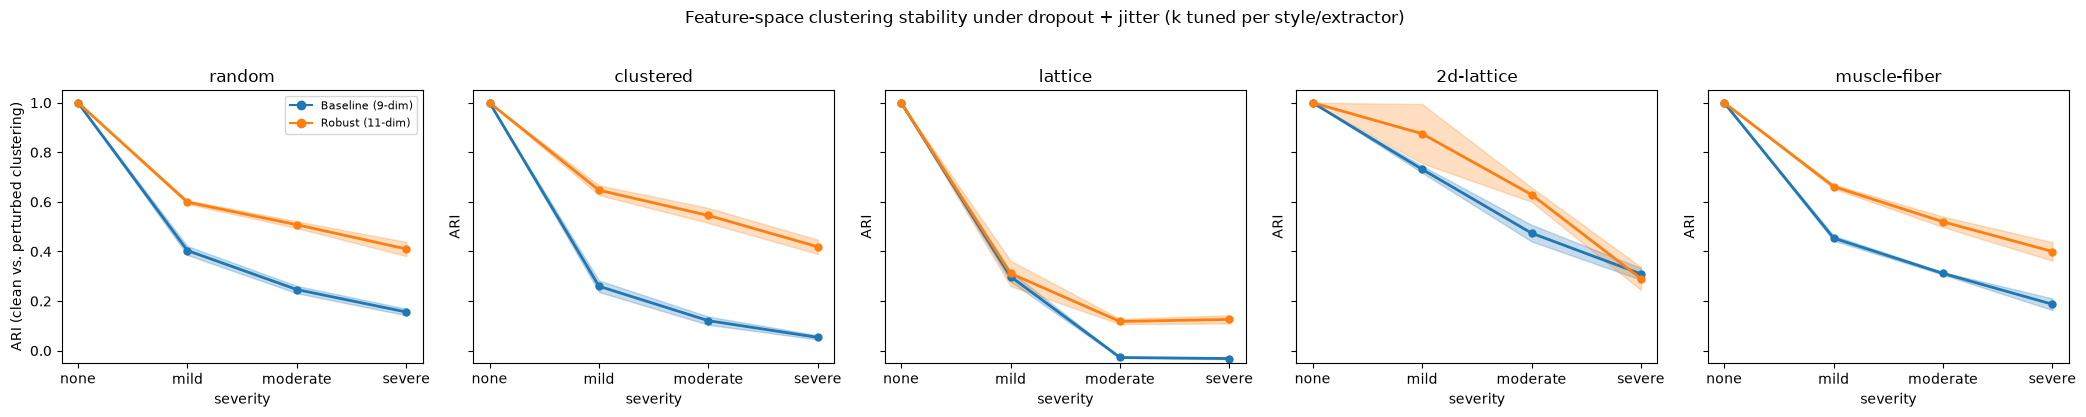

In [7]:
fig, axes = plt.subplots(1, len(STYLES), figsize=(4.2 * len(STYLES), 4), sharey=True)
for ext_name in EXTRACTOR_LABELS:
    data_per_style = [severity_data[(style, ext_name)] for style in STYLES]
    ErrorMetricsVisualizer.plot_parameter_sweep(
        axes=axes, x=severities, data_per_metric=data_per_style, y_labels=["ARI"] * len(STYLES), titles=STYLES, x_label='severity',
        colors=[EXTRACTOR_COLORS[ext_name]] * len(STYLES),
    )
for ax in axes:
    ax.set_ylim(-0.05, 1.05)

axes[0].set_ylabel('ARI (clean vs. perturbed clustering)')
axes[0].legend(
    handles=[plt.Line2D([0], [0], color=EXTRACTOR_COLORS[n], marker='o', label=n) for n in EXTRACTOR_LABELS],
    fontsize=8,
)
fig.suptitle('Feature-space clustering stability under dropout + jitter (k tuned per style/extractor)', y=1.03)
plt.tight_layout()
plt.savefig('../results/13_extractor_comparison_clustering_stability.png', dpi=300, bbox_inches='tight')
plt.show()

## Part B — ICP convergence under dropout + jitter

For each cloud style, run `MultiStartICP` with `NearestNeighborMatcher` driven by
each feature extractor, under a clean condition and a degraded condition (dropout +
measurement noise). Compares rotation error, translation error, residuals, and
convergence delta over iterations, plus wall-time across seeds.

In [8]:
N_POINTS_ICP = 1200
K_NEIGHBORS_ICP = 15
N_STARTS = 6
N_SEEDS = 3
T_SCALE = 8.0
MAX_ITER = 80

DROPOUT_DEGRADED = 0.2
NOISE_STD_DEGRADED = 1.0

In [9]:
icp_results: dict[tuple[str, str, str], Any] = {}

for style in STYLES:
    experiment_kwargs: dict[str, Any] = {'n': N_POINTS_ICP, 'style': style, 't_scale': T_SCALE}
    for ext_name, ext_cls in zip(EXTRACTOR_LABELS, EXTRACTOR_CLASSES):
        matcher = NearestNeighborMatcher(feature_extractor=ext_cls(k=K_NEIGHBORS_ICP))
        icp = MultiStartICP(icp=ICP(matcher=matcher, max_iter=MAX_ITER), n_starts=N_STARTS, verbose=False, record_history=False)

        icp_results[(style, ext_name, 'clean')] = fit_multi_seed(
            icp, seeds=list(range(N_SEEDS)), verbose=False, experiment_kwargs=experiment_kwargs,
        )
        icp_results[(style, ext_name, 'degraded')] = fit_multi_seed(
            icp, seeds=list(range(N_SEEDS)), dropout_prob=DROPOUT_DEGRADED, verbose=False,
            experiment_kwargs={**experiment_kwargs, 'noise_std': NOISE_STD_DEGRADED},
        )

print('ICP sweep done:', len(icp_results), 'runs')

TypeError: MultiStartICP.__init__() got an unexpected keyword argument 'record_history'

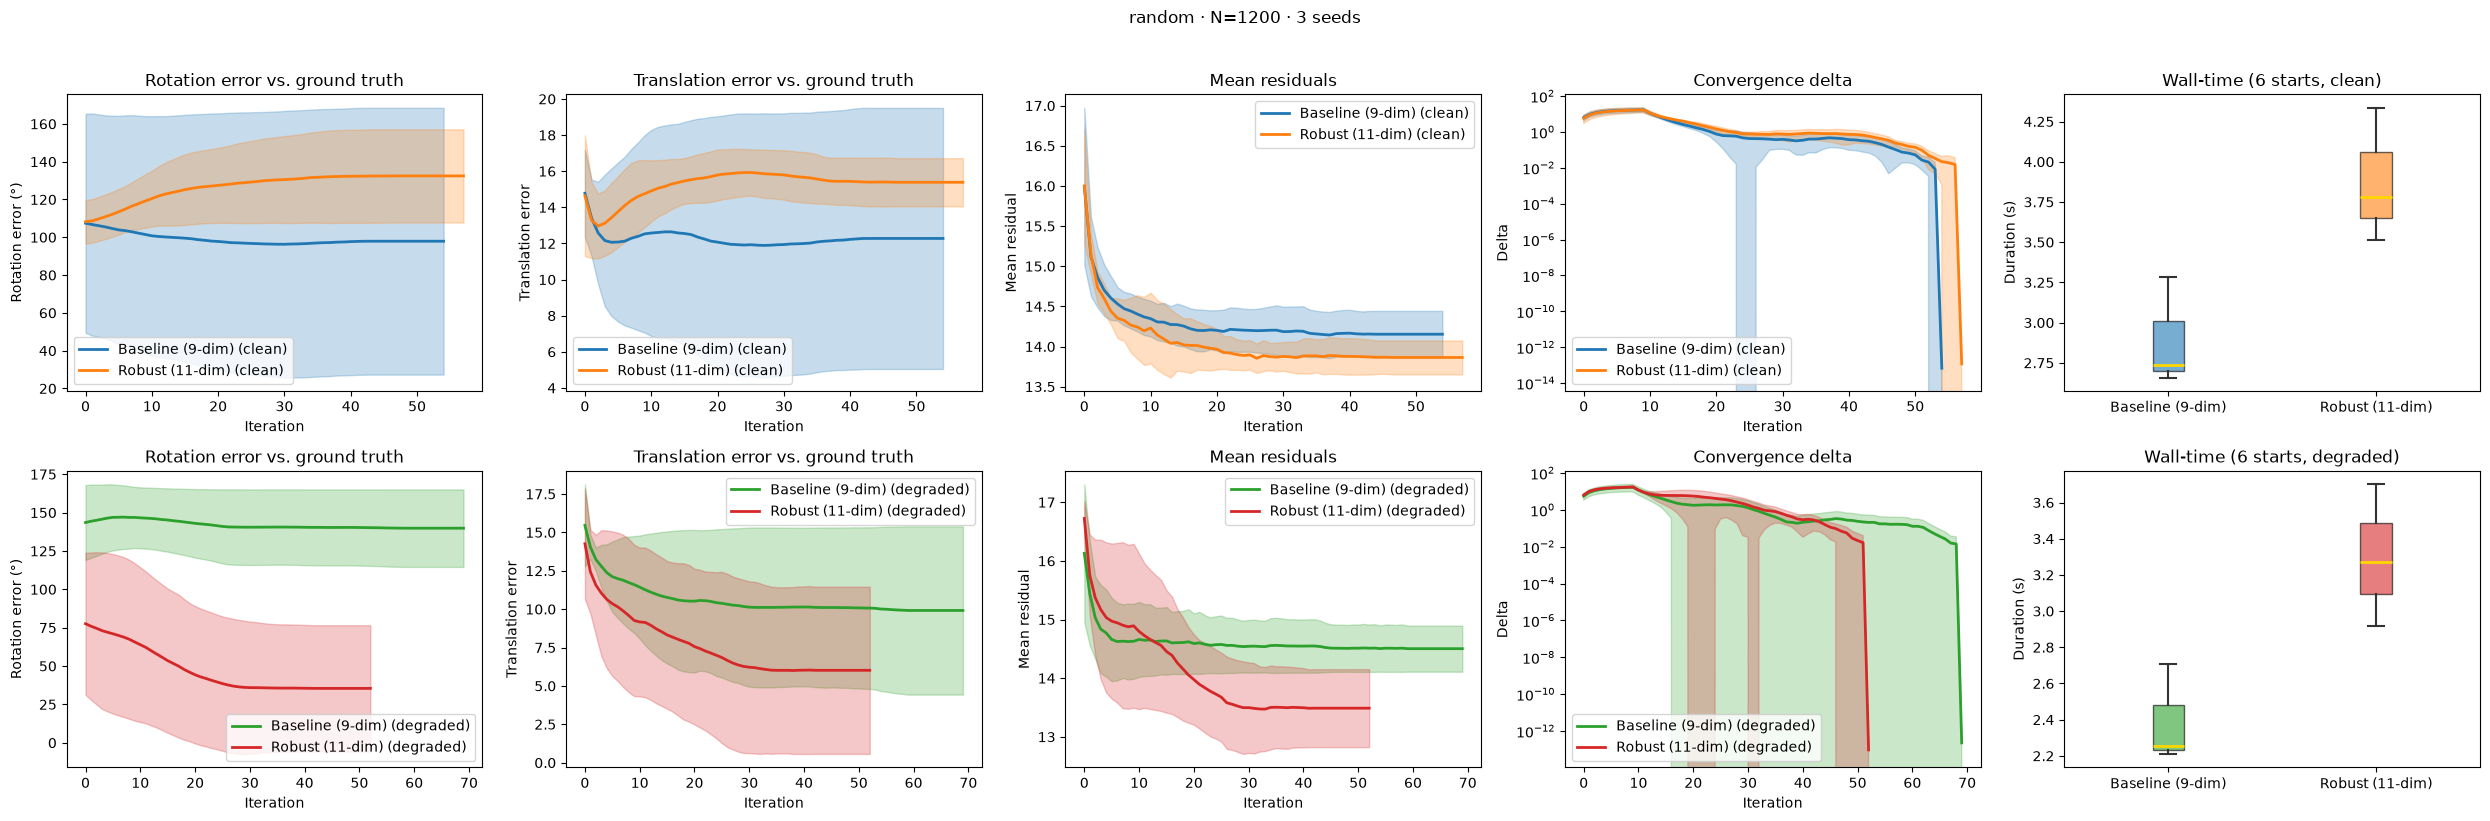

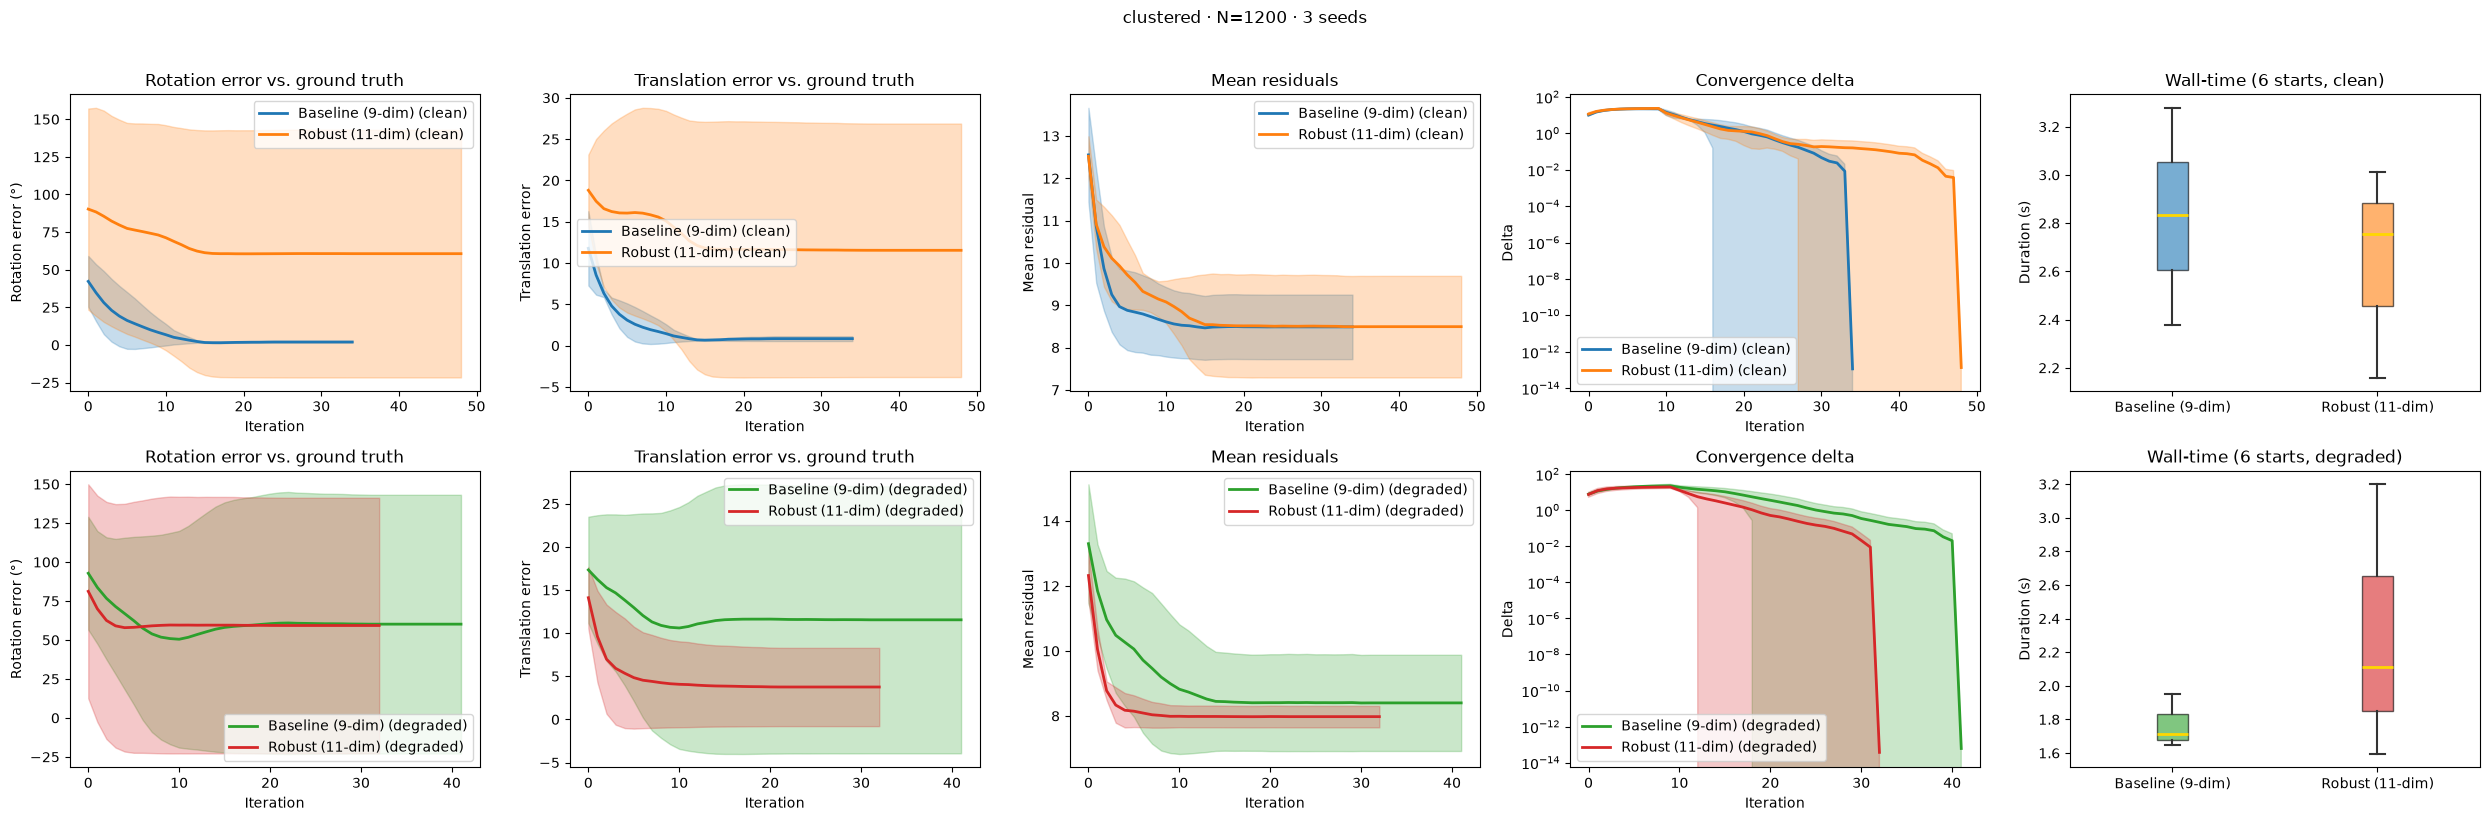

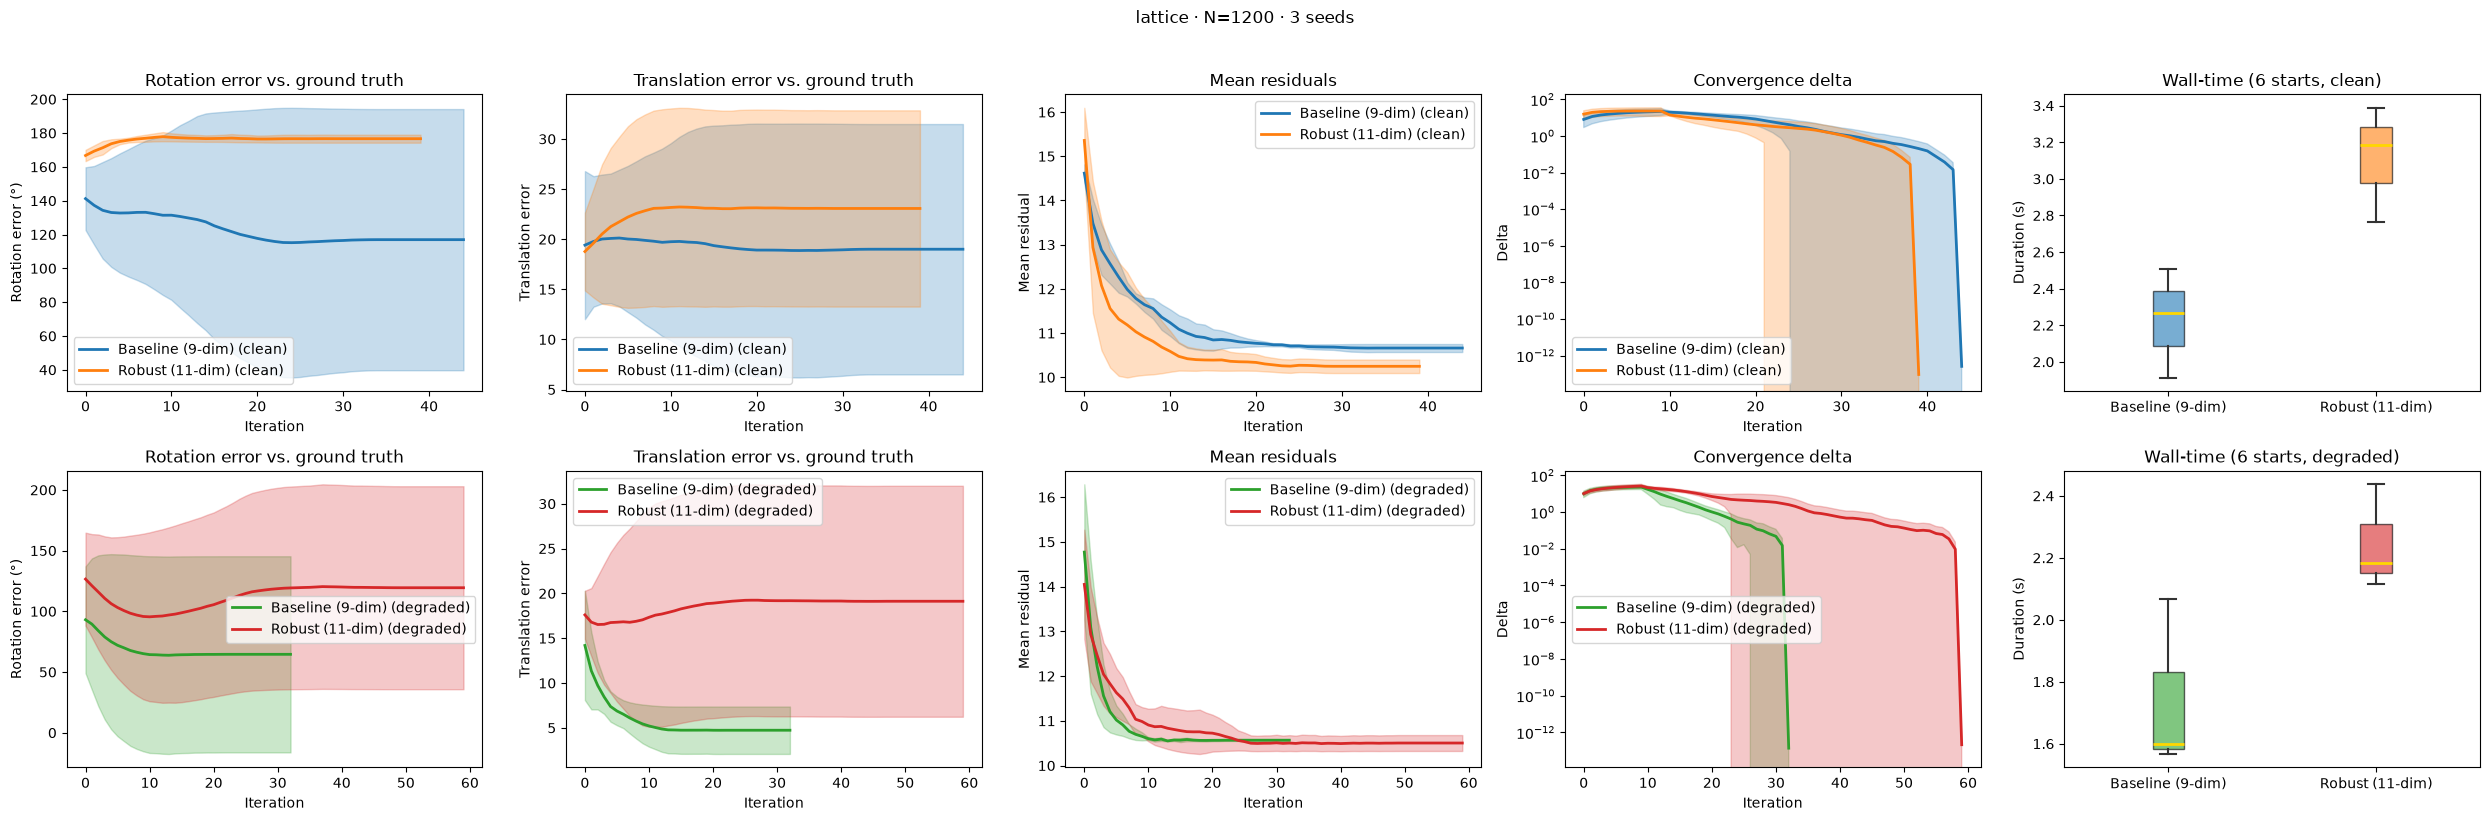

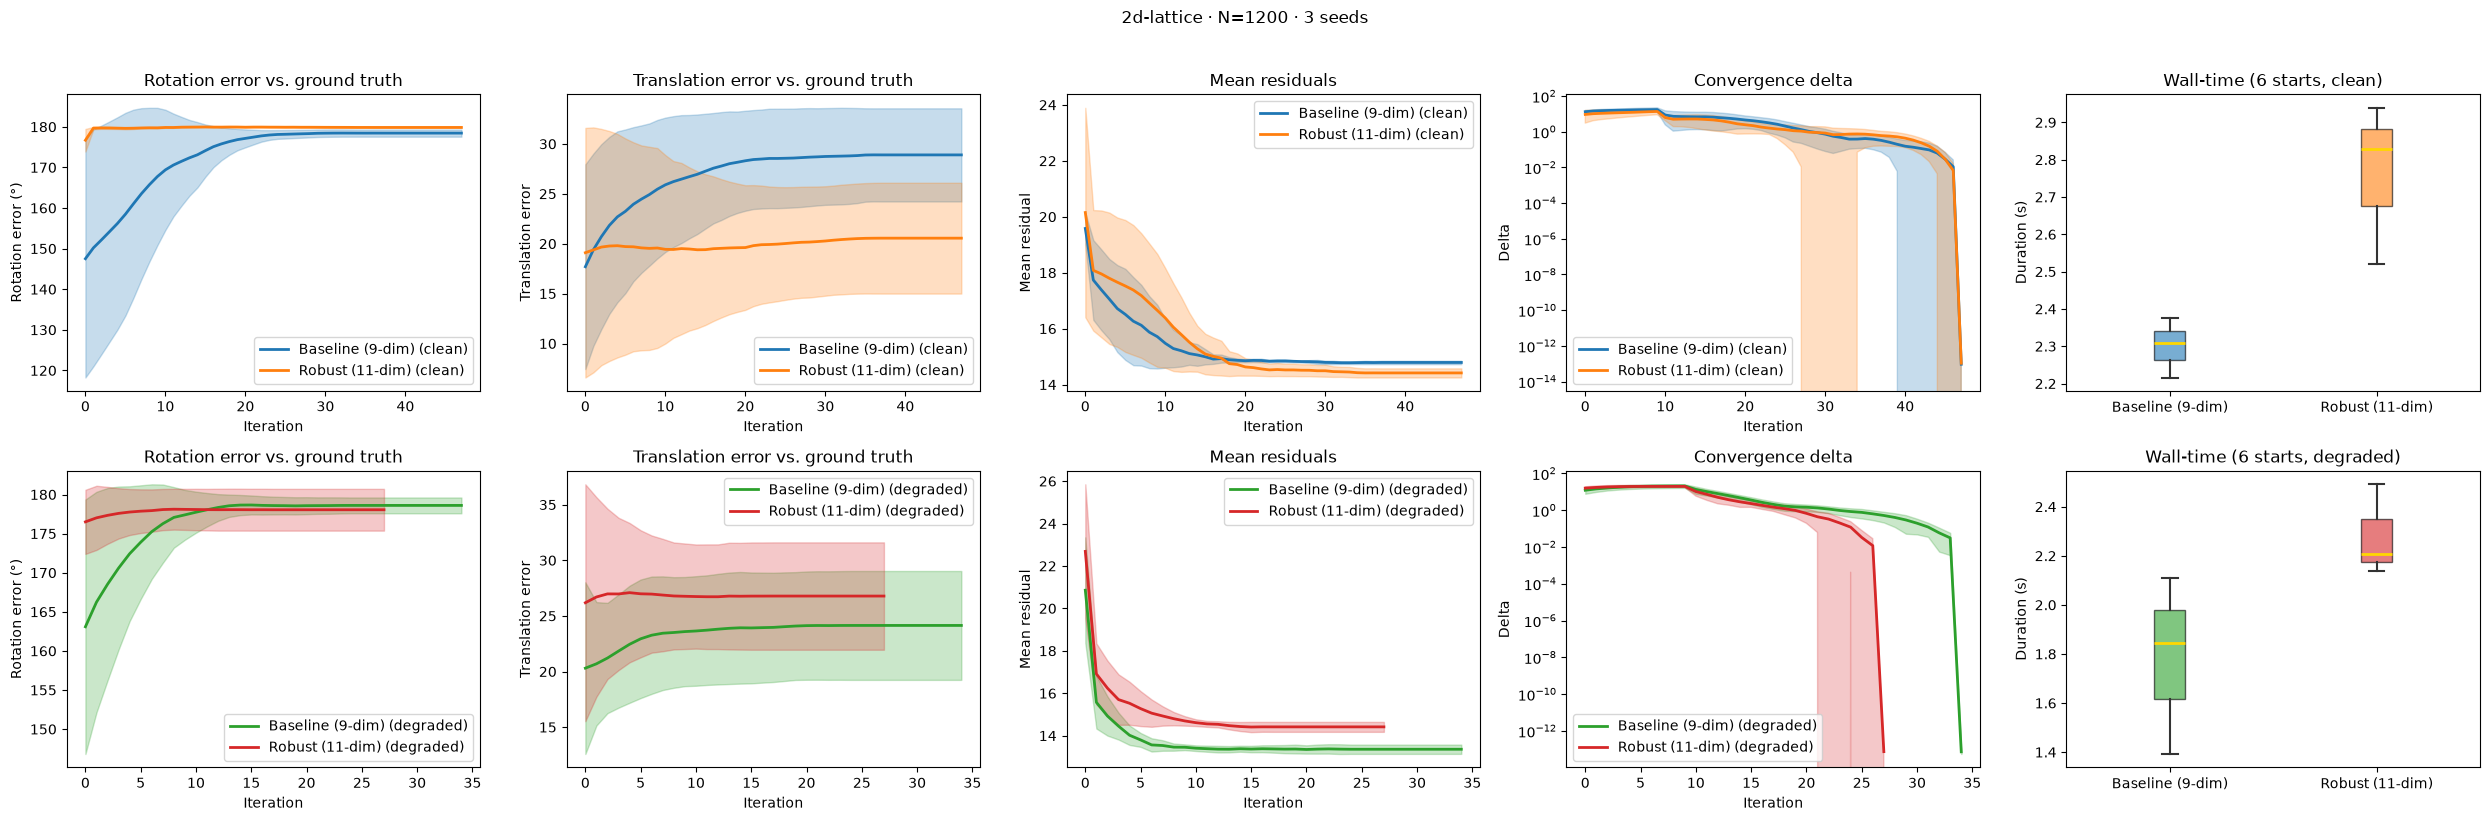

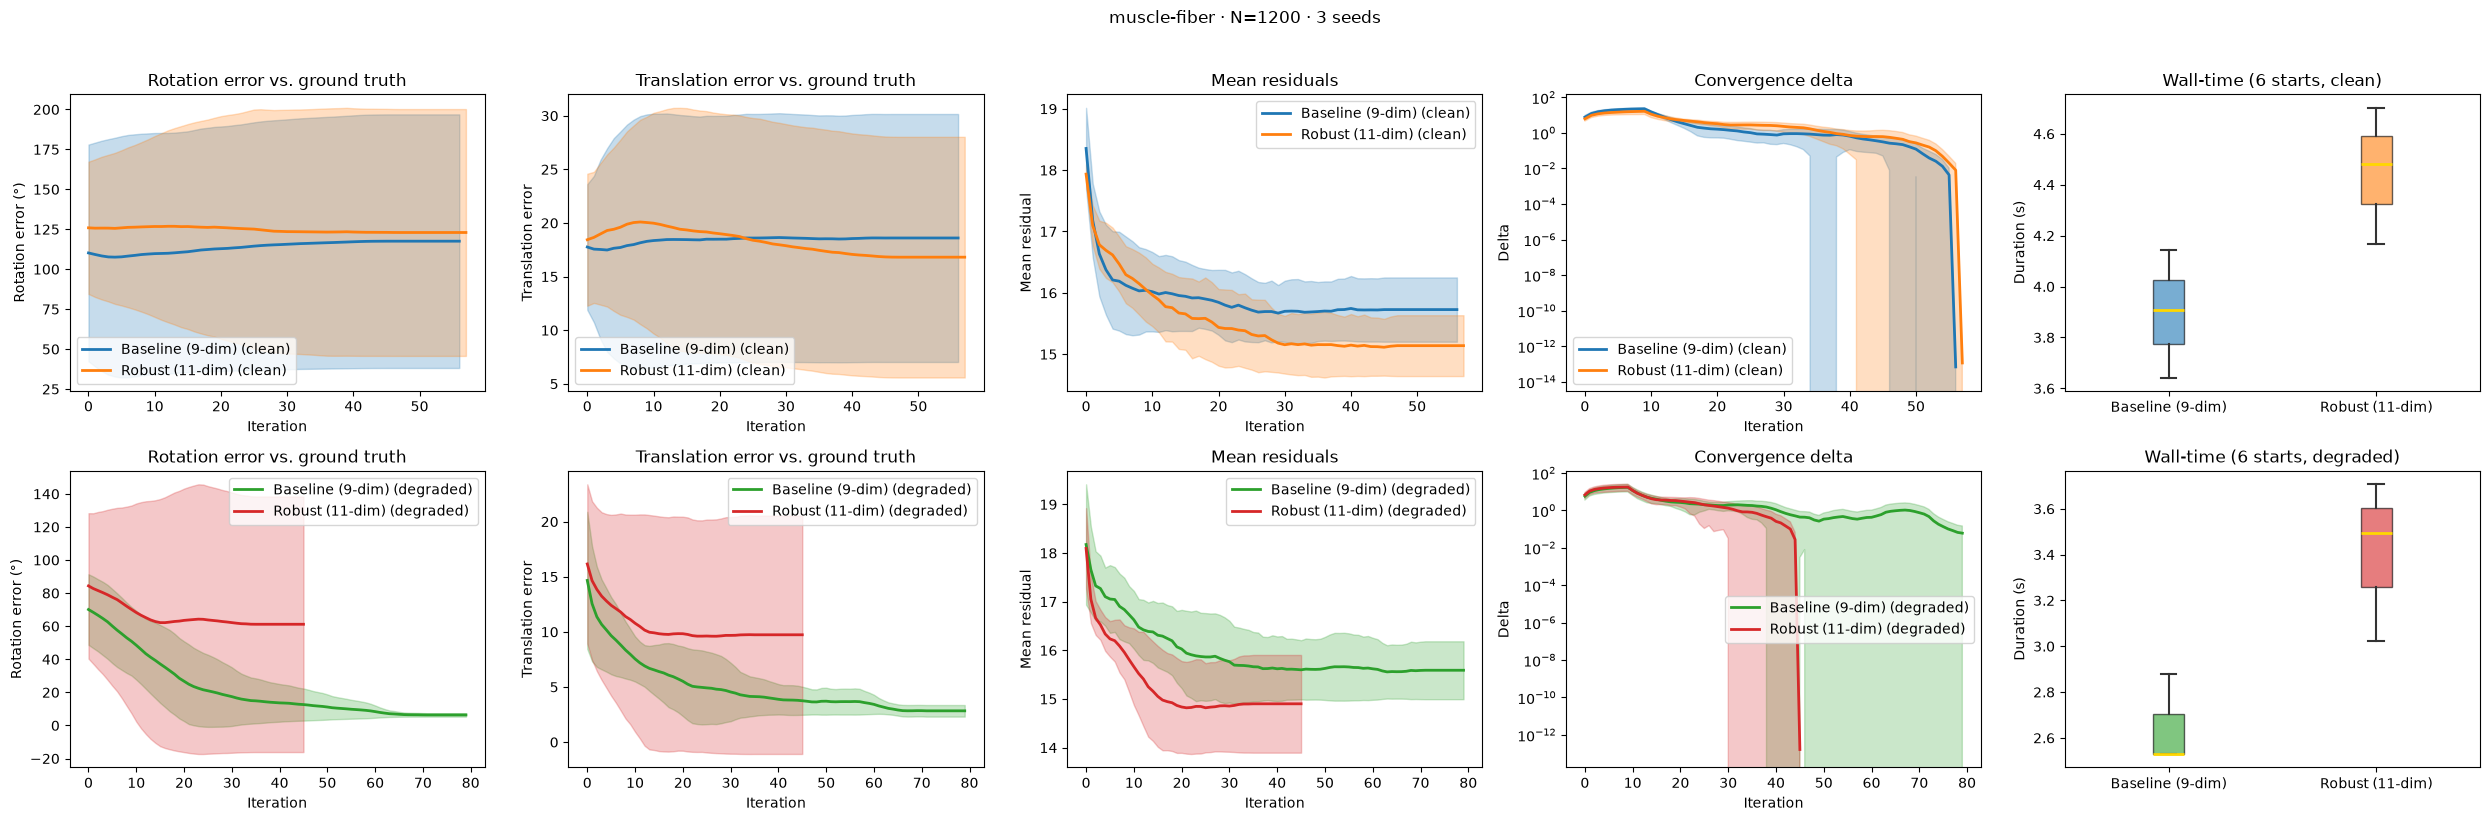

In [ ]:
for style in STYLES:
    fig, axes = plt.subplots(2, 5, figsize=(25, 8))
    for row, condition in enumerate(['clean', 'degraded']):
        results = [icp_results[(style, name, condition)].results for name in EXTRACTOR_LABELS]
        experiments = [icp_results[(style, name, condition)].experiments for name in EXTRACTOR_LABELS]
        durations = [icp_results[(style, name, condition)].durations_s for name in EXTRACTOR_LABELS]
        row_labels = [f'{name} ({condition})' for name in EXTRACTOR_LABELS]
        row_colors = ['tab:blue', 'tab:orange'] if condition == 'clean' else ['tab:green', 'tab:red']

        ErrorMetricsVisualizer.plot_rot_error_per_iterations(axes[row, 0], results, experiments, row_labels, row_colors)
        ErrorMetricsVisualizer.plot_translation_error_per_iterations(axes[row, 1], results, experiments, row_labels, row_colors)
        ErrorMetricsVisualizer.plot_residual_errors_per_iteration(axes[row, 2], results, row_labels, row_colors)
        ErrorMetricsVisualizer.plot_delta_per_iterations(axes[row, 3], results, row_labels, row_colors)
        TimeVisualizer.plot_duration_distribution(axes[row, 4], durations, EXTRACTOR_LABELS, row_colors)
        axes[row, 4].set_title(f'Wall-time ({N_STARTS} starts, {condition})')

    fig.suptitle(f'{style} · N={N_POINTS_ICP} · {N_SEEDS} seeds', y=1.02)
    plt.tight_layout()
    plt.savefig(f'../results/13_extractor_comparison_icp_{style}.png', dpi=200, bbox_inches='tight')
    plt.show()

In [ ]:
summary_rows = []
for style in STYLES:
    for ext_name in EXTRACTOR_LABELS:
        for condition in ['clean', 'degraded']:
            res = icp_results[(style, ext_name, condition)]
            summary_rows.append([
                style, ext_name, condition,
                f'{np.mean(res.rotation_errors):.2f}',
                f'{np.mean(res.translation_errors):.2f}',
                f'{np.mean(res.mean_closest_point_residuals):.3f}',
                f'{np.mean(res.durations_s):.2f}',
            ])

print(tabulate(
    summary_rows,
    headers=['style', 'extractor', 'condition', 'rot err (deg)', 'trans err', 'mean closest-point residual', 'runtime (s)'],
    tablefmt='github',
))

| style        | extractor        | condition   |   rot err (deg) |   trans err |   mean closest-point residual |   runtime (s) |
|--------------|------------------|-------------|-----------------|-------------|-------------------------------|---------------|
| random       | Baseline (9-dim) | clean       |           97.92 |       12.28 |                         3.42  |          2.89 |
| random       | Baseline (9-dim) | degraded    |          139.84 |        9.92 |                         3.424 |          2.39 |
| random       | Robust (11-dim)  | clean       |          132.48 |       15.39 |                         3.577 |          3.88 |
| random       | Robust (11-dim)  | degraded    |           35.44 |        6.02 |                         3.015 |          3.3  |
| clustered    | Baseline (9-dim) | clean       |            1.98 |        0.85 |                         1.936 |          2.83 |
| clustered    | Baseline (9-dim) | degraded    |           60.16 |       11.54 |         